<a href="https://colab.research.google.com/github/marktxm/DockerFiles/blob/master/Madrid_CC3_Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Madrid_CC3_Project2
- Classical supervised regression techniques
- Students Performance Dataset
- Reference Chapter 6 Regression

## 1. Dataset Understanding and Exploratory Data Analysis (EDA)

In [ ]:
# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
# get the data
import google.colab.files as files
uploaded = files.upload()

Saving StudentsPerformance.csv to StudentsPerformance.csv


In [ ]:
# assuming the StudentsPerformance.csv fie is uploaded
StudentsPerf = pd.read_csv('StudentsPerformance.csv')

In [ ]:
# check data
StudentsPerf.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Data inspection

In [ ]:
StudentsPerf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [19]:

# Basic dataset inspection
print("Column names:")
print(StudentsPerf.columns.tolist())
print("Data types:")
print(StudentsPerf.dtypes)
print("Missing values by column:")
print(StudentsPerf.isnull().sum())


Column names:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']
Data types:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object
Missing values by column:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


## EDA notes
-The dataset contains 1,000 rows and 8 columns.
- It includes both categorical and numerical variables.
- There are no NaN values, which simplifies preprocessing.
- I will create preprocessing pipelines with imputers for best practices.

In [20]:
# statistics
print("Numerical data:")
display(StudentsPerf.describe())

print("Non-numeric (Categorical) data:")
display(StudentsPerf.describe(include='object'))

Numerical data:


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Non-numeric (Categorical) data:


,gender,race/ethnicity,parental level of education,lunch,test preparation course
count,1000,1000,1000,1000,1000
unique,2,5,6,2,2
top,female,group C,some college,standard,none
freq,518,319,226,645,642


In [21]:
# Separate numerical and categorical columns
numerical_cols = StudentsPerf.select_dtypes(include='number').columns.tolist()
categorical_cols = StudentsPerf.select_dtypes(exclude='number').columns.tolist()

print('Numerical columns:', numerical_cols)
print('Categorical columns:', categorical_cols)

Numerical columns: ['math score', 'reading score', 'writing score']
Categorical columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


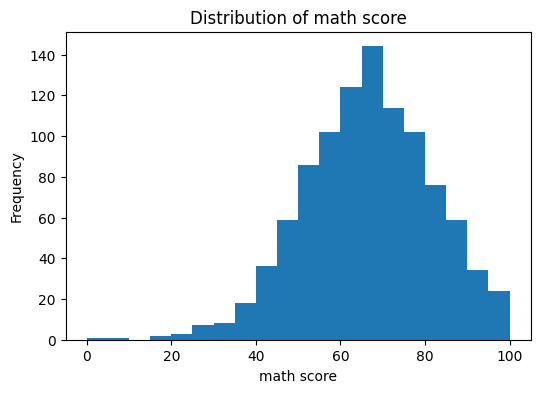

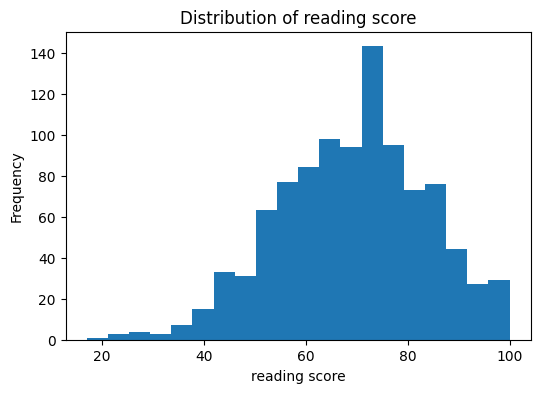

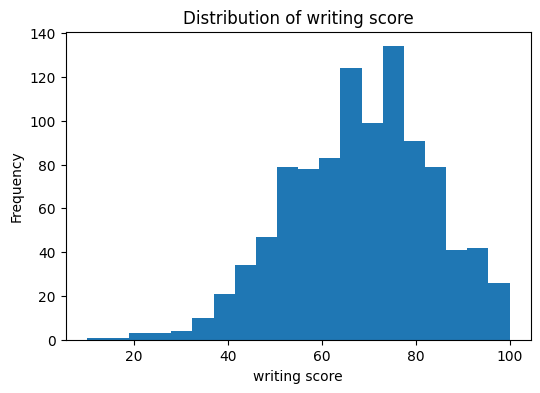

In [22]:
# Histograms features
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    plt.hist(StudentsPerf[col], bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

## Histograms data results
- slightly skewed left
- Median seems to be 60 with tail at 80

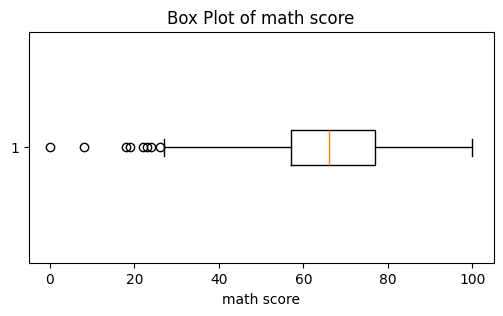

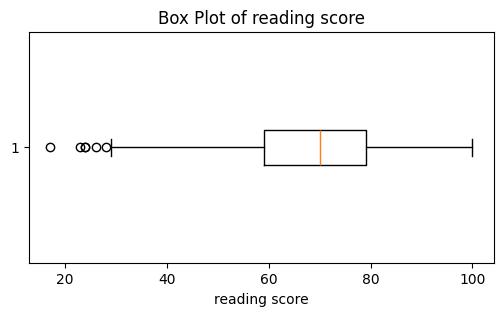

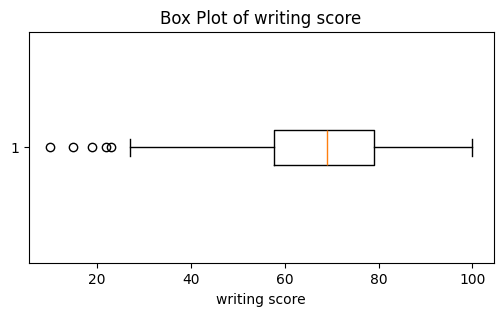

In [23]:
# Box plots to inspect possible outliers
for col in numerical_cols:
    plt.figure(figsize=(6,3))
    plt.boxplot(StudentsPerf[col], vert=False)
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.show()

## BoxPlot data results
- Outliers present

## Summary
### Missing values
- The dataset does not contain missing values.
- We need the imputation steps in the pipeline
  - so the workflow remains robust and consistent with preprocessing practices.

### Outliers
- The box plots show some extreme values in IQR fence,
  - but they may be useful for student performance data.
- We'll not remove outliers because they may represent valid student outcomes,
  - and removing them may affect the usefulness of the model.

               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


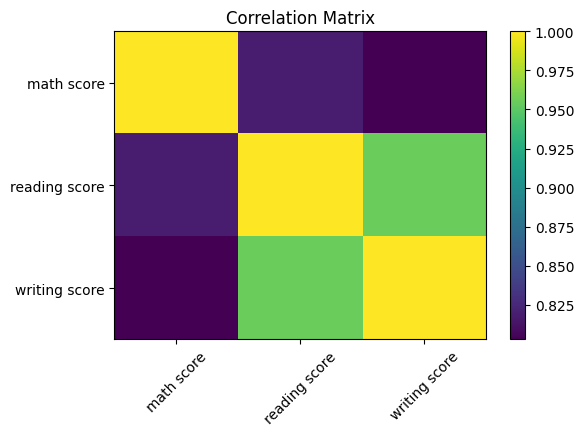

In [24]:
# Correlation for numerical variables
corr_matrix = StudentsPerf[numerical_cols].corr()
print(corr_matrix)

plt.figure(figsize=(6,4))
plt.imshow(corr_matrix, cmap='viridis', aspect='auto')
plt.colorbar()
plt.xticks(range(len(numerical_cols)), numerical_cols, rotation=45)
plt.yticks(range(len(numerical_cols)), numerical_cols)
plt.title('Correlation Matrix')
plt.show()

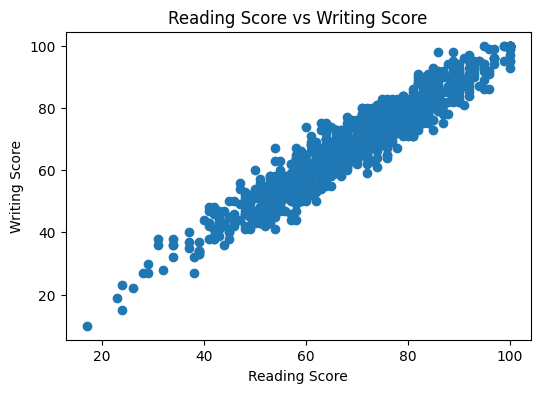

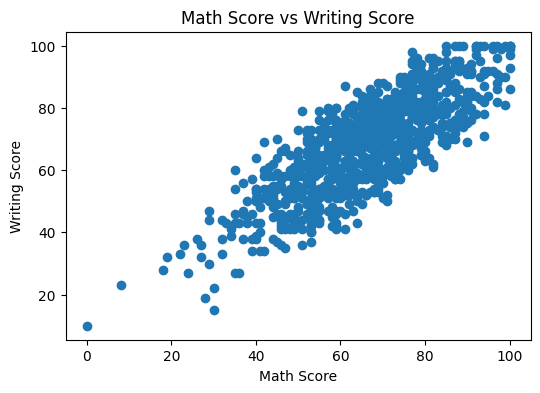

In [25]:
# Relationship predictors and target
plt.figure(figsize=(6,4))
plt.scatter(StudentsPerf['reading score'], StudentsPerf['writing score'])
plt.title('Reading Score vs Writing Score')
plt.xlabel('Reading Score')
plt.ylabel('Writing Score')
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(StudentsPerf['math score'], StudentsPerf['writing score'])
plt.title('Math Score vs Writing Score')
plt.xlabel('Math Score')
plt.ylabel('Writing Score')
plt.show()

## Analysis and Insights
- The Reading score has a strong linear relationship with writing score.
- Also, the Math score has a positive relationship with writing score,
  - but it is weaker than the reading score.
- The distributions of the score columns are fairly well-behaved for classical regression.
- Since classical regression works best when relationships are fairly stable and not being distorted by unusual points.
- The target is strongly related to at least one numerical feature; a linear regression model is reasonable.
- A decision tree may still capture non-linear splits and interaction effects, so it is a useful comparison model.

### Resources
- https://online.stat.psu.edu/stat500/Lesson09?utm_source=chatgpt.com
- https://www.geeksforgeeks.org/data-visualization/what-is-box-plot-and-the-condition-of-outliers/
- https://online.stat.psu.edu/stat500/Lesson09

## 2. Data Preprocessing
- **Steps for preprocessing**
1. **Define the target** as `writing score`.
2. **Split the dataset** franform to training and testing sets using an 80/20 split.
3. **Impute missing values** to keep the pipeline clean. However, we confirmed no NaN values.
4. **One-hot encode categorical variables** so regression models have numerical input.
5. **Scale numerical features** with StandardScaler. This helps the linear regression model.

In [26]:
# Define features and target
target = 'writing score'
X = StudentsPerf.drop(columns=[target])
y = StudentsPerf[target]

num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training set shape:', X_train.shape)
print('Testing set shape:', X_test.shape)

Training set shape: (800, 7)
Testing set shape: (200, 7)


In [27]:
# Execute Preprocessing pipelines
numeric_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_preprocessor, num_cols),
    ('cat', categorical_preprocessor, cat_cols)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['math score', 'reading score']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'race/ethnicity',
                                  'parental level of education', 'lunch',
                                  'test preparation course'])])

## 3. Model Development

Requirements: two regression models
- LinearRegression
- DecisionTreeRegressor

### Resource
- https://www.freecodecamp.org/news/how-to-build-and-train-linear-and-logistic-regression-ml-models-in-python/
- https://www.geeksforgeeks.org/machine-learning/linear-regression-python-implementation/

In [28]:
# Linear Regression pipeline
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)
print('Linear Regression model trained successfully.')

Linear Regression model trained successfully.


In [29]:
# Decision Tree pipeline with hyperparameter tuning
tree_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

param_grid = {
    'model__max_depth': [3, 5, 7, 10],
    'model__min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    tree_model,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=1
)

grid_search.fit(X_train, y_train)
best_tree_model = grid_search.best_estimator_
tree_predictions = best_tree_model.predict(X_test)

print('Best Decision Tree parameters:', grid_search.best_params_)

Best Decision Tree parameters: {'model__max_depth': 5, 'model__min_samples_split': 2}


## 4. Model Evaluation

I evaluate both regression models using the required metrics:
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- R² Score

In [30]:
# Evaluation function
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

linear_results = regression_metrics(y_test, linear_predictions)
tree_results = regression_metrics(y_test, tree_predictions)

results_StudentsPerf = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree Regressor'],
    'MSE': [linear_results[0], tree_results[0]],
    'RMSE': [linear_results[1], tree_results[1]],
    'MAE': [linear_results[2], tree_results[2]],
    'R2 Score': [linear_results[3], tree_results[3]]
})

results_StudentsPerf

,Model,MSE,RMSE,MAE,R2 Score
0,Linear Regression,14.911021,3.861479,3.200272,0.938133
1,Decision Tree Regressor,24.930450,4.993040,3.954350,0.896561


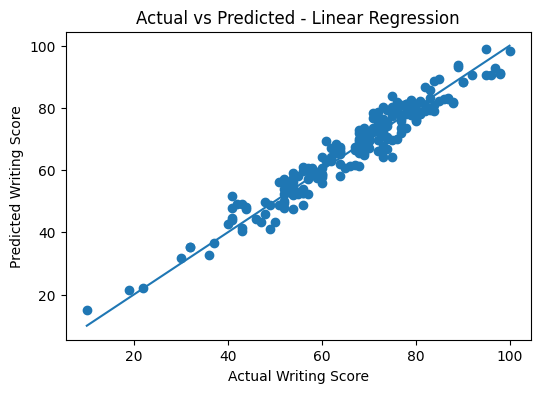

In [31]:
# Actual vs predicted plot for Linear Regression
plt.figure(figsize=(6,4))
plt.scatter(y_test, linear_predictions)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title('Actual vs Predicted - Linear Regression')
plt.xlabel('Actual Writing Score')
plt.ylabel('Predicted Writing Score')
plt.show()

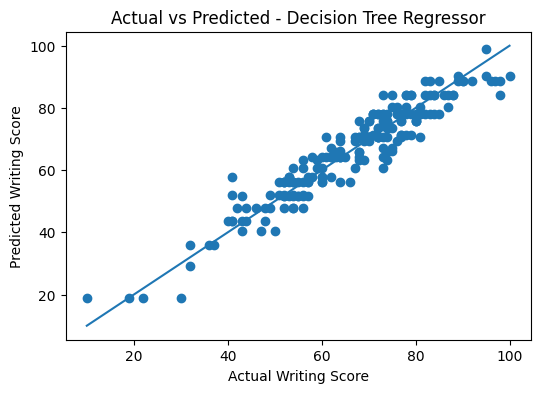

In [32]:

# Actual vs predicted plot for Decision Tree
plt.figure(figsize=(6,4))
plt.scatter(y_test, tree_predictions)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title('Actual vs Predicted - Decision Tree Regressor')
plt.xlabel('Actual Writing Score')
plt.ylabel('Predicted Writing Score')
plt.show()

### Evaluation
The metrics and plots show that Linear Regression performs better than the tuned Decision Tree Regressor on this dataset.

In this notebook run, we see;

Linear Regression  
- MSE = 14.91
- RMSE = 3.86
- MAE = 3.20
- R2 = 0.94

Decision Tree Regressor
- MSE = 24.93
- RMSE = 4.99
- MAE = 3.95
- R2 = 0.90

The EDA shows to have a strong linear relationship between reading score and writing score.

Since the relationship is mostly linear, the linear model generalizes better. The decision tree is reasonable, but it appears less accurate.

# Conclusion
Linear Regression performed better with this dataset because the target variable has a strong linear relationship with the numerical predictors, especially **reading score**.